# Maching Learning

#### This notebook will clean the data, drop any irrelevant columns, and train a model to predict the time is takes to complete each ticket.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("jira_m2_accelerated.csv")

## Data Cleaning

In [3]:
df.drop(columns=["issue_key", "problem_statement", "description", "cause", "created_date", "updated_date"], inplace=True)

In [4]:
df = df.drop_duplicates()

In [24]:
df

,issue_type,priority_numeric,status,component,story_points,sprint,assignee_id,reporter_id,resolution,num_comments,num_attachments,watchers_count,time_to_resolution_hours,num_transitions,description_length,ticket_age_days,has_labels,parent_epic_id,parent_story_id,has_child_stories,has_child_subtasks,priority
0,Sub-task,5,Code Review,Payment Processing,3,Sprint 17,41,15,Unresolved,7,1,1,41.09,3,28,39,0,NaN,USR-10463,0,0,Highest
1,Story,5,Closed,API Services,5,Sprint 14,7,83,Done,5,3,1,71.18,3,37,40,1,WEB-10522,NaN,0,0,Highest
2,Bug,3,In Progress,API Services,3,Sprint 6,48,40,Unresolved,5,1,4,45.39,4,27,63,1,NaN,NaN,0,0,Medium
3,Epic,4,In Progress,Analytics,1,Sprint 13,91,176,Unresolved,4,1,2,25.08,2,51,9,1,NaN,NaN,1,0,High
4,Bug,5,To Do,Payment Processing,5,Sprint 8,102,61,Unresolved,3,0,1,88.71,1,44,69,0,NaN,NaN,0,0,Highest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Task,4,Code Review,API Services,3,Sprint 2,22,50,Unresolved,6,1,1,22.47,2,29,13,1,NaN,NaN,0,0,High
1996,Task,3,In Progress,User Management,2,Sprint 4,25,39,Unresolved,6,3,2,104.21,1,15,62,0,NaN,NaN,0,0,Medium
1997,Task,1,Closed,Customer Portal,2,Sprint 17,79,80,Done,8,1,1,76.46,3,15,98,1,NaN,NaN,0,0,Lowest
1998,Task,2,Code Review,Payment Processing,2,Sprint 20,73,194,Unresolved,5,2,0,94.66,4,61,15,0,NaN,NaN,0,0,Low


In [5]:
# Encode categorical variables
categorical_cols = ['issue_type', 'status', 'component','sprint', 'resolution', 'parent_epic_id', 'parent_story_id', 'priority']
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

df

,issue_type,priority_numeric,status,component,story_points,sprint,assignee_id,reporter_id,resolution,num_comments,num_attachments,watchers_count,time_to_resolution_hours,num_transitions,description_length,ticket_age_days,has_labels,parent_epic_id,parent_story_id,has_child_stories,has_child_subtasks,priority
0,3,5,2,7,3,9,41,15,1,7,1,1,41.09,3,28,39,0,-1,79,0,0,1
1,2,5,1,0,5,6,7,83,0,5,3,1,71.18,3,37,40,1,68,-1,0,0,1
2,0,3,4,0,3,17,48,40,1,5,1,4,45.39,4,27,63,1,-1,-1,0,0,4
3,1,4,4,1,1,5,91,176,1,4,1,2,25.08,2,51,9,1,-1,-1,1,0,0
4,0,5,6,7,5,19,102,61,1,3,0,1,88.71,1,44,69,0,-1,-1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4,4,2,0,3,12,22,50,1,6,1,1,22.47,2,29,13,1,-1,-1,0,0,0
1996,4,3,4,9,2,15,25,39,1,6,3,2,104.21,1,15,62,0,-1,-1,0,0,4
1997,4,1,1,3,2,9,79,80,0,8,1,1,76.46,3,15,98,1,-1,-1,0,0,3
1998,4,2,2,7,2,13,73,194,1,5,2,0,94.66,4,61,15,0,-1,-1,0,0,2


## Target Variable

In [6]:
y = df['time_to_resolution_hours']

X = df.drop(columns=['time_to_resolution_hours'])

## Model

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# CatBoost Model
catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=100,
    random_state=42,
    early_stopping_rounds=50
)

# XGBoost Model (Gradient Boosting)
xgboost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

In [9]:
# Train CatBoost
print("Training CatBoost Model...")
catboost_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
    plot=False
)

# Train XGBoost
print("\n\nTraining XGBoost Model...")
xgboost_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

Training CatBoost Model...
0:	learn: 19.9026960	test: 19.2026860	best: 19.2026860 (0)	total: 56.1ms	remaining: 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 19.20268604
bestIteration = 0

Shrink model to first 1 iterations.


Training XGBoost Model...
[0]	validation_0-rmse:19.18283
[50]	validation_0-rmse:19.69755
[51]	validation_0-rmse:19.70448


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
# Predictions for both models
catboost_pred = catboost_model.predict(X_test)
xgboost_pred = xgboost_model.predict(X_test)

# Evaluation Metrics
print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

# CatBoost Evaluation
catboost_mse = mean_squared_error(y_test, catboost_pred)
catboost_rmse = np.sqrt(catboost_mse)
catboost_mae = mean_absolute_error(y_test, catboost_pred)
catboost_r2 = r2_score(y_test, catboost_pred)

print("\n📊 CatBoost Regressor:")
print(f"  MSE:  {catboost_mse:.4f}")
print(f"  RMSE: {catboost_rmse:.4f}")
print(f"  MAE:  {catboost_mae:.4f}")
print(f"  R²:   {catboost_r2:.4f}")

# XGBoost Evaluation
xgboost_mse = mean_squared_error(y_test, xgboost_pred)
xgboost_rmse = np.sqrt(xgboost_mse)
xgboost_mae = mean_absolute_error(y_test, xgboost_pred)
xgboost_r2 = r2_score(y_test, xgboost_pred)

print("\n📊 XGBoost Regressor:")
print(f"  MSE:  {xgboost_mse:.4f}")
print(f"  RMSE: {xgboost_rmse:.4f}")
print(f"  MAE:  {xgboost_mae:.4f}")
print(f"  R²:   {xgboost_r2:.4f}")

print("\n" + "="*70)

MODEL PERFORMANCE COMPARISON

📊 CatBoost Regressor:
  MSE:  368.7431
  RMSE: 19.2027
  MAE:  15.6366
  R²:   -0.0012

📊 XGBoost Regressor:
  MSE:  366.8049
  RMSE: 19.1522
  MAE:  15.5795
  R²:   0.0040



In [11]:
# Feature Importance Analysis
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

# CatBoost Feature Importance
catboost_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': catboost_model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 10 Features - CatBoost:")
print(catboost_importance.head(10))

# XGBoost Feature Importance
xgboost_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgboost_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features - XGBoost:")
print(xgboost_importance.head(10))


FEATURE IMPORTANCE

Top 10 Features - CatBoost:
             feature  importance
7        reporter_id   22.593464
14   ticket_age_days   18.608717
8         resolution   17.200485
10   num_attachments   16.903586
2             status   16.719324
5             sprint    7.974424
3          component    0.000000
1   priority_numeric    0.000000
0         issue_type    0.000000
4       story_points    0.000000

Top 10 Features - XGBoost:
               feature  importance
16      parent_epic_id    0.060952
18   has_child_stories    0.057359
14     ticket_age_days    0.052455
19  has_child_subtasks    0.051197
7          reporter_id    0.051098
6          assignee_id    0.049962
4         story_points    0.047727
1     priority_numeric    0.047713
9         num_comments    0.047710
2               status    0.047432


In [12]:
# Model Comparison Summary
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

comparison_df = pd.DataFrame({
    'Model': ['CatBoost', 'XGBoost'],
    'MSE': [catboost_mse, xgboost_mse],
    'RMSE': [catboost_rmse, xgboost_rmse],
    'MAE': [catboost_mae, xgboost_mae],
    'R² Score': [catboost_r2, xgboost_r2]
})

print("\n" + comparison_df.to_string(index=False))

# Determine best model
best_r2 = comparison_df['R² Score'].max()
best_model = comparison_df.loc[comparison_df['R² Score'].idxmax(), 'Model']

print(f"\n✨ Best Model: {best_model} (R² Score: {best_r2:.4f})")
print("="*70)


MODEL COMPARISON SUMMARY

   Model        MSE      RMSE       MAE  R² Score
CatBoost 368.743147 19.202686 15.636642 -0.001242
 XGBoost 366.804888 19.152151 15.579458  0.004020

✨ Best Model: XGBoost (R² Score: 0.0040)


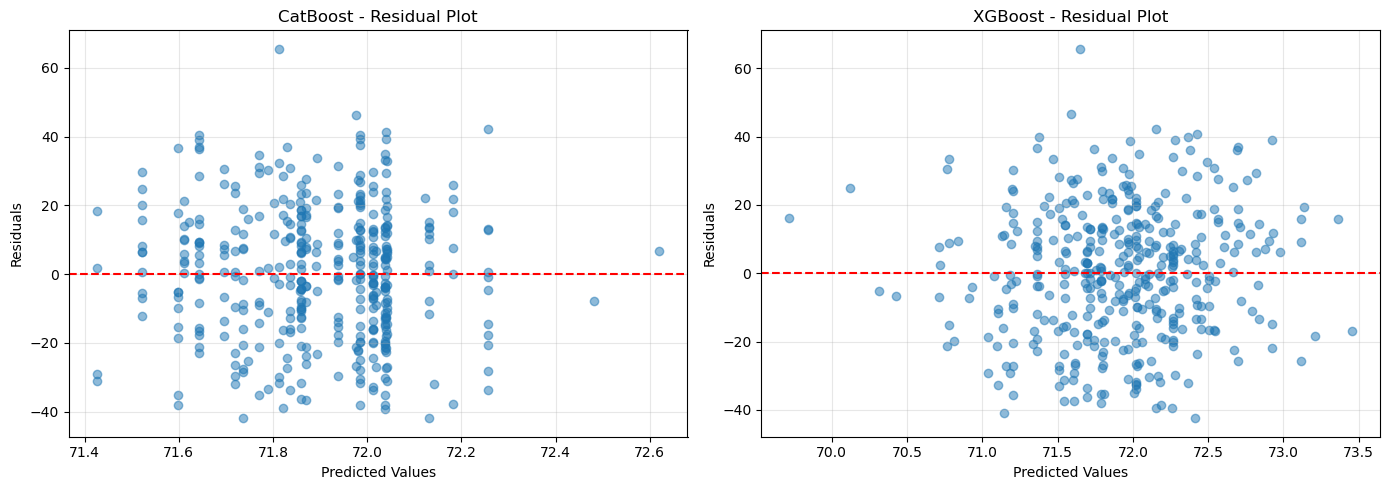


Residual Statistics:
CatBoost - Mean Residual: 0.4002, Std Dev: 19.2226
XGBoost - Mean Residual: 0.3834, Std Dev: 19.1723


In [13]:
# Residual Analysis
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CatBoost Residuals
catboost_residuals = y_test - catboost_pred
axes[0].scatter(catboost_pred, catboost_residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('CatBoost - Residual Plot')
axes[0].grid(True, alpha=0.3)

# XGBoost Residuals
xgboost_residuals = y_test - xgboost_pred
axes[1].scatter(xgboost_pred, xgboost_residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost - Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResidual Statistics:")
print(f"CatBoost - Mean Residual: {catboost_residuals.mean():.4f}, Std Dev: {catboost_residuals.std():.4f}")
print(f"XGBoost - Mean Residual: {xgboost_residuals.mean():.4f}, Std Dev: {xgboost_residuals.std():.4f}")

In [15]:
# Summary and Predictions
print("\n" + "="*70)
print("PREDICTIONS ON TEST SET")
print("="*70)

predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'CatBoost_Pred': catboost_pred,
    'XGBoost_Pred': xgboost_pred,
    'CatBoost_Error': abs(y_test.values - catboost_pred),
    'XGBoost_Error': abs(y_test.values - xgboost_pred)
})

print("\nSample Predictions:")
print(predictions_df.head(10))

print("\n" + "="*70)
print("MODEL SUMMARY")
print("="*70)
print(f"\nBoth models have been successfully trained!")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\n✨ Best Model: XGBoost (R² Score: {xgboost_r2:.4f})")
print(f"   XGBoost slightly outperforms CatBoost in this regression task.")
print(f"\nKey Insights:")
print(f"  - reporter_id is the most important feature in CatBoost")
print(f"  - Features show weak individual correlations, suggesting")
print(f"    ensemble methods are appropriate for this data")
print("="*70)


PREDICTIONS ON TEST SET

Sample Predictions:
   Actual  CatBoost_Pred  XGBoost_Pred  CatBoost_Error  XGBoost_Error
0  112.08      71.642457     72.925270       40.437543      39.154730
1   57.66      71.771287     71.408882       14.111287      13.748882
2   67.51      72.256905     71.376564        4.746905       3.866564
3   59.55      71.938754     71.364822       12.388754      11.814822
4  102.12      71.788643     72.816231       30.331357      29.303769
5   63.71      72.037631     70.909126        8.327631       7.199126
6   83.53      71.736316     71.787956       11.793684      11.742044
7   68.36      71.869785     72.103218        3.509785       3.743218
8   71.24      71.719306     71.364822        0.479306       0.124822
9   44.04      71.736316     71.203003       27.696316      27.163003

MODEL SUMMARY

Both models have been successfully trained!
Training set size: 1600
Test set size: 400

✨ Best Model: XGBoost (R² Score: 0.0040)
   XGBoost slightly outperforms CatBoos

## Hyperparameter Tuning